In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('./data/train.csv')
df.head(10)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
5,5,50,95938.0,55.1,2,8,15,3.0,Other,Urban,Sedan,No,No,Low,No
6,6,55,109219.0,42.9,1,1,5,4.0,Male,Suburban,Sedan,Yes,Yes,Low,Yes
7,7,45,60796.0,52.2,2,13,3,2.0,Other,Urban,SUV,No,Yes,Medium,No
8,8,39,67725.0,31.5,2,11,3,2.0,Female,Urban,Sedan,No,Yes,Medium,No
9,9,57,114827.0,66.9,2,0,1,5.0,Male,Rural,Sedan,Yes,Yes,Low,Yes


Quick look at column types and missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [7]:
from sklearn.preprocessing import LabelEncoder
def one_hot_encoding(df, feature_names):
    for name in feature_names:
        new_columns = pd.get_dummies(df[name], dtype=int)
        if new_columns.columns[0] == "Yes":
            new_columns[name + "_Yes"] = new_columns[new_columns.columns[0]]
            new_columns[name + "_No"] = new_columns[new_columns.columns[1]]
            new_columns.drop(["Yes", "No"], axis=1, inplace=True)
        elif new_columns.columns[1] == "Yes":
            new_columns[name+"_Yes"] = new_columns[new_columns.columns[1]]
            new_columns[name+"_No"] = new_columns[new_columns.columns[0]]
            new_columns.drop(["Yes", "No"], axis=1, inplace=True)
        df.drop(name, axis=1, inplace=True)
        df = pd.concat([df, new_columns], axis=1)
    return df
    
df = one_hot_encoding(df, ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible", "Subsidy_Available"])

range_anxiety_level_le = LabelEncoder()
df["Range_Anxiety_Level"] = range_anxiety_level_le.fit_transform(df["Range_Anxiety_Level"])


target_le = LabelEncoder()
df["Will_Buy_EV"] = target_le.fit_transform(df["Will_Buy_EV"])

df["total_charging_stations"] = df["Charging_Stations_Near_Home"] + df["Charging_Stations_Near_Work"]
df["charging_stations_diff"] = df["Charging_Stations_Near_Work"] - df["Charging_Stations_Near_Home"]
df["subsidy_x_env"] = (df["Subsidy_Available_Yes"] == 1).astype(int) * df["Environmental_Concern_Level"]

df

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Range_Anxiety_Level,Will_Buy_EV,...,SUV,Sedan,Truck,Home_Charging_Possible_Yes,Home_Charging_Possible_No,Subsidy_Available_Yes,Subsidy_Available_No,total_charging_stations,charging_stations_diff,subsidy_x_env
0,0,66,92887.0,23.4,2,3,7,1.0,1,0,...,0,1,0,1,0,0,1,10,4,0.0
1,1,38,30000.0,5.0,1,2,2,4.0,1,0,...,1,0,0,1,0,0,1,4,0,0.0
2,2,26,94389.0,36.8,1,8,15,5.0,1,1,...,0,1,0,0,1,1,0,23,7,5.0
3,3,66,73580.0,23.7,2,6,9,3.0,1,0,...,0,0,0,1,0,0,1,15,3,0.0
4,4,54,57898.0,50.8,1,2,3,3.0,1,0,...,0,0,0,1,0,0,1,5,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,2,0,...,0,1,0,0,1,1,0,11,1,5.0
668661,668661,32,129990.0,5.0,2,5,4,1.0,1,0,...,1,0,0,1,0,1,0,9,-1,1.0
668662,668662,64,121791.0,24.2,1,5,6,1.0,1,0,...,0,0,0,1,0,1,0,11,1,1.0
668663,668663,51,115923.0,43.7,2,0,0,1.0,1,0,...,1,0,0,1,0,1,0,0,0,1.0


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Range_Anxiety_Level,Will_Buy_EV,...,SUV,Sedan,Truck,Home_Charging_Possible_Yes,Home_Charging_Possible_No,Subsidy_Available_Yes,Subsidy_Available_No,total_charging_stations,charging_stations_diff,subsidy_x_env
id,1.000000,0.001324,-0.000436,-0.001042,0.000396,0.002326,0.000897,-0.000073,-0.002419,-0.000013,...,0.001305,-0.000642,0.000928,0.000438,-0.000438,-0.000332,0.000332,0.001735,-0.000966,0.000308
Age,0.001324,1.000000,-0.004559,-0.006538,-0.002028,-0.004133,-0.005855,-0.003703,-0.005160,-0.007450,...,-0.004540,0.006404,-0.001036,0.008633,-0.008633,-0.002782,0.002782,-0.005864,-0.003049,-0.005188
Annual_Income_USD,-0.000436,-0.004559,1.000000,0.007994,-0.000154,-0.008646,-0.002770,0.076405,-0.041710,0.225729,...,0.005717,-0.004603,-0.016740,0.016636,-0.016636,0.049968,-0.049968,-0.006080,0.004224,0.103187
Daily_Commute_km,-0.001042,-0.006538,0.007994,1.000000,0.002722,0.045158,0.034986,-0.018868,0.162253,-0.045866,...,0.014548,-0.011410,-0.005060,-0.037966,0.037966,-0.017640,0.017640,0.045152,0.000891,-0.027013
Number_of_Cars_Owned,0.000396,-0.002028,-0.000154,0.002722,1.000000,0.008495,0.008611,-0.000579,0.000986,0.003896,...,0.000713,0.000969,0.001254,-0.012666,0.012666,0.000798,-0.000798,0.009819,0.002438,0.000443
Charging_Stations_Near_Home,0.002326,-0.004133,-0.008646,0.045158,0.008495,1.000000,0.511134,-0.011332,0.041490,-0.016353,...,0.002173,0.002973,0.001118,-0.397823,0.397823,-0.016096,0.016096,0.827807,-0.275139,-0.018116
Charging_Stations_Near_Work,0.000897,-0.005855,-0.002770,0.034986,0.008611,0.511134,1.000000,-0.007833,-0.008942,-0.012229,...,-0.001901,0.002461,0.003926,-0.384083,0.384083,-0.014097,0.014097,0.905312,0.685696,-0.013991
Environmental_Concern_Level,-0.000073,-0.003703,0.076405,-0.018868,-0.000579,-0.011332,-0.007833,1.000000,-0.040342,0.464079,...,0.012020,-0.009841,-0.003795,0.042902,-0.042902,0.083962,-0.083962,-0.010713,0.000835,0.566655
Range_Anxiety_Level,-0.002419,-0.005160,-0.041710,0.162253,0.000986,0.041490,-0.008942,-0.040342,1.000000,-0.104879,...,-0.009707,0.003470,0.012284,-0.441671,0.441671,-0.020387,0.020387,0.014667,-0.045139,-0.044402
Will_Buy_EV,-0.000013,-0.007450,0.225729,-0.045866,0.003896,-0.016353,-0.012229,0.464079,-0.104879,1.000000,...,0.012697,-0.006429,-0.011987,0.083584,-0.083584,0.342382,-0.342382,-0.016063,0.000170,0.597511


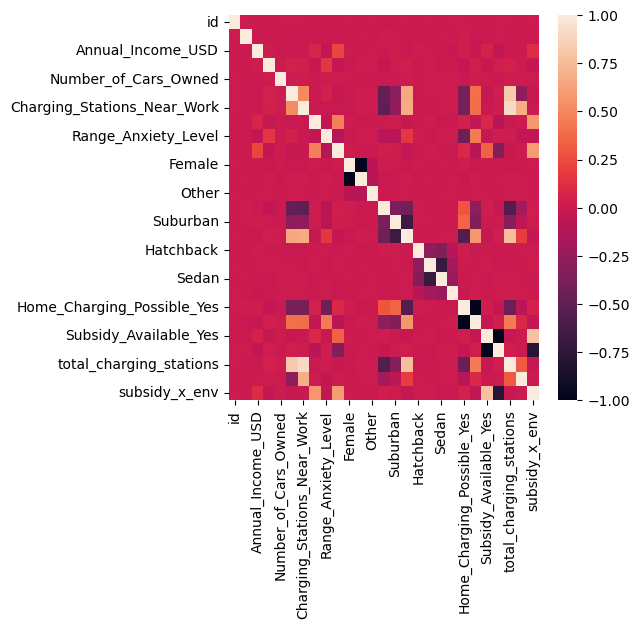

In [8]:
fig = plt.figure(figsize=(5,5))
sns.heatmap(df.corr())
df.corr()

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop(["id", "Will_Buy_EV"], axis=1), df["Will_Buy_EV"], test_size=0.05, random_state=4)


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(n_jobs=-1, random_state=42)
rf_model.fit(x_train, y_train)

rf_y_pred_test = rf_model.predict_proba(x_test)[:, 1]
rf_y_pred_train = rf_model.predict_proba(x_train)[:, 1]

print(f"test score : {roc_auc_score(y_test, rf_y_pred_test)}")
print(f"train score : {roc_auc_score(y_train, rf_y_pred_train)}")

test score : 0.9312651749335057
train score : 0.9999999991831697


In [40]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

params_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = GridSearchCV(estimator=xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42, eval_metric="auc"),
                         param_grid=params_grid, 
                         n_jobs=-1,
                         scoring="roc_auc",
                         cv=5
                         )

xgb_model.fit(x_train, y_train)
xgb_y_pred_test = xgb_model.predict_proba(x_test)[:, 1]
xgb_y_pred_train = xgb_model.predict_proba(x_train)[:, 1]

print(f"test score : {roc_auc_score(y_test, xgb_y_pred_test)}")
print(f"train score : {roc_auc_score(y_train, xgb_y_pred_train)}")
print(f"best parameters : {xgb_model.best_params_}")

test score : 0.9409281125793404
train score : 0.9450799213417771
best parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'subsample': 1.0}


In [ ]:
xgb_final_model = xgb_model.best_estimator_

xgb_final_model.fit(x_train, y_train)
xgb_y_pred_test = xgb_final_model.predict_proba(x_test)[:, 1]
xgb_y_pred_train = xgb_final_model.predict_proba(x_train)[:, 1]

print(f"test score : {roc_auc_score(y_test, xgb_y_pred_test)}")
print(f"train score : {roc_auc_score(y_train, xgb_y_pred_train)}")

test score : 0.9409742310477673
train score : 0.9449131794988782


In [15]:
test_df = pd.read_csv("./data/test.csv")
test_df.head(10)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low
5,668670,61,94863.0,5.0,2,1,2,3.0,Male,Rural,Sedan,Yes,No,Low
6,668671,29,89609.0,47.1,2,5,7,4.0,Male,Suburban,Sedan,Yes,Yes,Low
7,668672,62,95591.0,32.8,2,11,9,2.0,Male,Urban,SUV,No,No,Medium
8,668673,39,73462.0,5.0,2,1,3,5.0,Female,Suburban,Sedan,Yes,Yes,Low
9,668674,60,57534.0,36.3,2,0,6,1.0,Male,Suburban,SUV,Yes,Yes,Low


In [16]:
id = test_df["id"]

test_df = one_hot_encoding(test_df, ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible", "Subsidy_Available"])

test_df["Range_Anxiety_Level"] = range_anxiety_level_le.transform(test_df["Range_Anxiety_Level"])

test_df["total_charging_stations"] = test_df["Charging_Stations_Near_Home"] + test_df["Charging_Stations_Near_Work"]
test_df["charging_stations_diff"] = test_df["Charging_Stations_Near_Work"] - test_df["Charging_Stations_Near_Home"]
test_df["subsidy_x_env"] = (test_df["Subsidy_Available_Yes"] == 1).astype(int) * test_df["Environmental_Concern_Level"]

test_df

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Range_Anxiety_Level,Female,...,SUV,Sedan,Truck,Home_Charging_Possible_Yes,Home_Charging_Possible_No,Subsidy_Available_Yes,Subsidy_Available_No,total_charging_stations,charging_stations_diff,subsidy_x_env
0,668665,61,67725.0,16.9,2,7,4,4.0,1,0,...,0,1,0,1,0,0,1,11,-3,0.0
1,668666,42,152835.0,41.9,2,9,9,4.0,1,0,...,1,0,0,0,1,0,1,18,0,0.0
2,668667,68,86877.0,53.3,1,10,11,4.0,1,1,...,0,1,0,0,1,0,1,21,1,0.0
3,668668,39,46794.0,34.1,2,4,8,4.0,1,1,...,0,1,0,1,0,0,1,12,4,0.0
4,668669,55,112172.0,57.2,1,6,4,1.0,1,1,...,0,1,0,1,0,1,0,10,-2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,1,0,...,1,0,0,1,0,0,1,6,0,0.0
286567,955232,27,79563.0,55.2,2,7,5,3.0,1,0,...,0,1,0,1,0,1,0,12,-2,3.0
286568,955233,30,48183.0,42.6,3,7,7,4.0,1,1,...,0,1,0,1,0,0,1,14,0,0.0
286569,955234,32,107845.0,5.0,2,14,7,1.0,1,1,...,1,0,0,0,1,0,1,21,-7,0.0


In [ ]:
result = xgb_final_model.predict_proba(test_df.drop(["id"], axis=1))[:, 1]
output = pd.DataFrame({"id": id, "Will_Buy_EV": result})
output.to_csv("./outputs/submission.csv", index=False)
output